In [ ]:
import aerosandbox as asb

# Dimension in meters

# -------------- FUSELAGE --------------

nose_length   = 0.204   # nose cone length
body_length   = 0.4     # rectangular section length
tail_length   = 0.750   # trapezoid tail length

nose_tip_wh = 0.04        # nose tip width

body_w = 0.15        # body width
body_h = 0.15        # body height

tail_w = 0.15         # tail tip width
tail_h = 0.04         # tail tip height

# x positions
x0 = 0.0                              # nose tip
x1 = nose_length                      # nose -> body
x2 = nose_length + body_length        # body -> tail
x3 = nose_length + body_length + tail_length  # tail tip

# -------------- WINGS --------------

x_root = 
z_wing = 
chord = 0.367
airfoil=asb.Airfoil("naca2412"),
x_tip =
half_span = 
z_wing = 
airfoil=asb.Airfoil("naca2412"),

SyntaxError: unmatched ')' (1489453140.py, line 31)

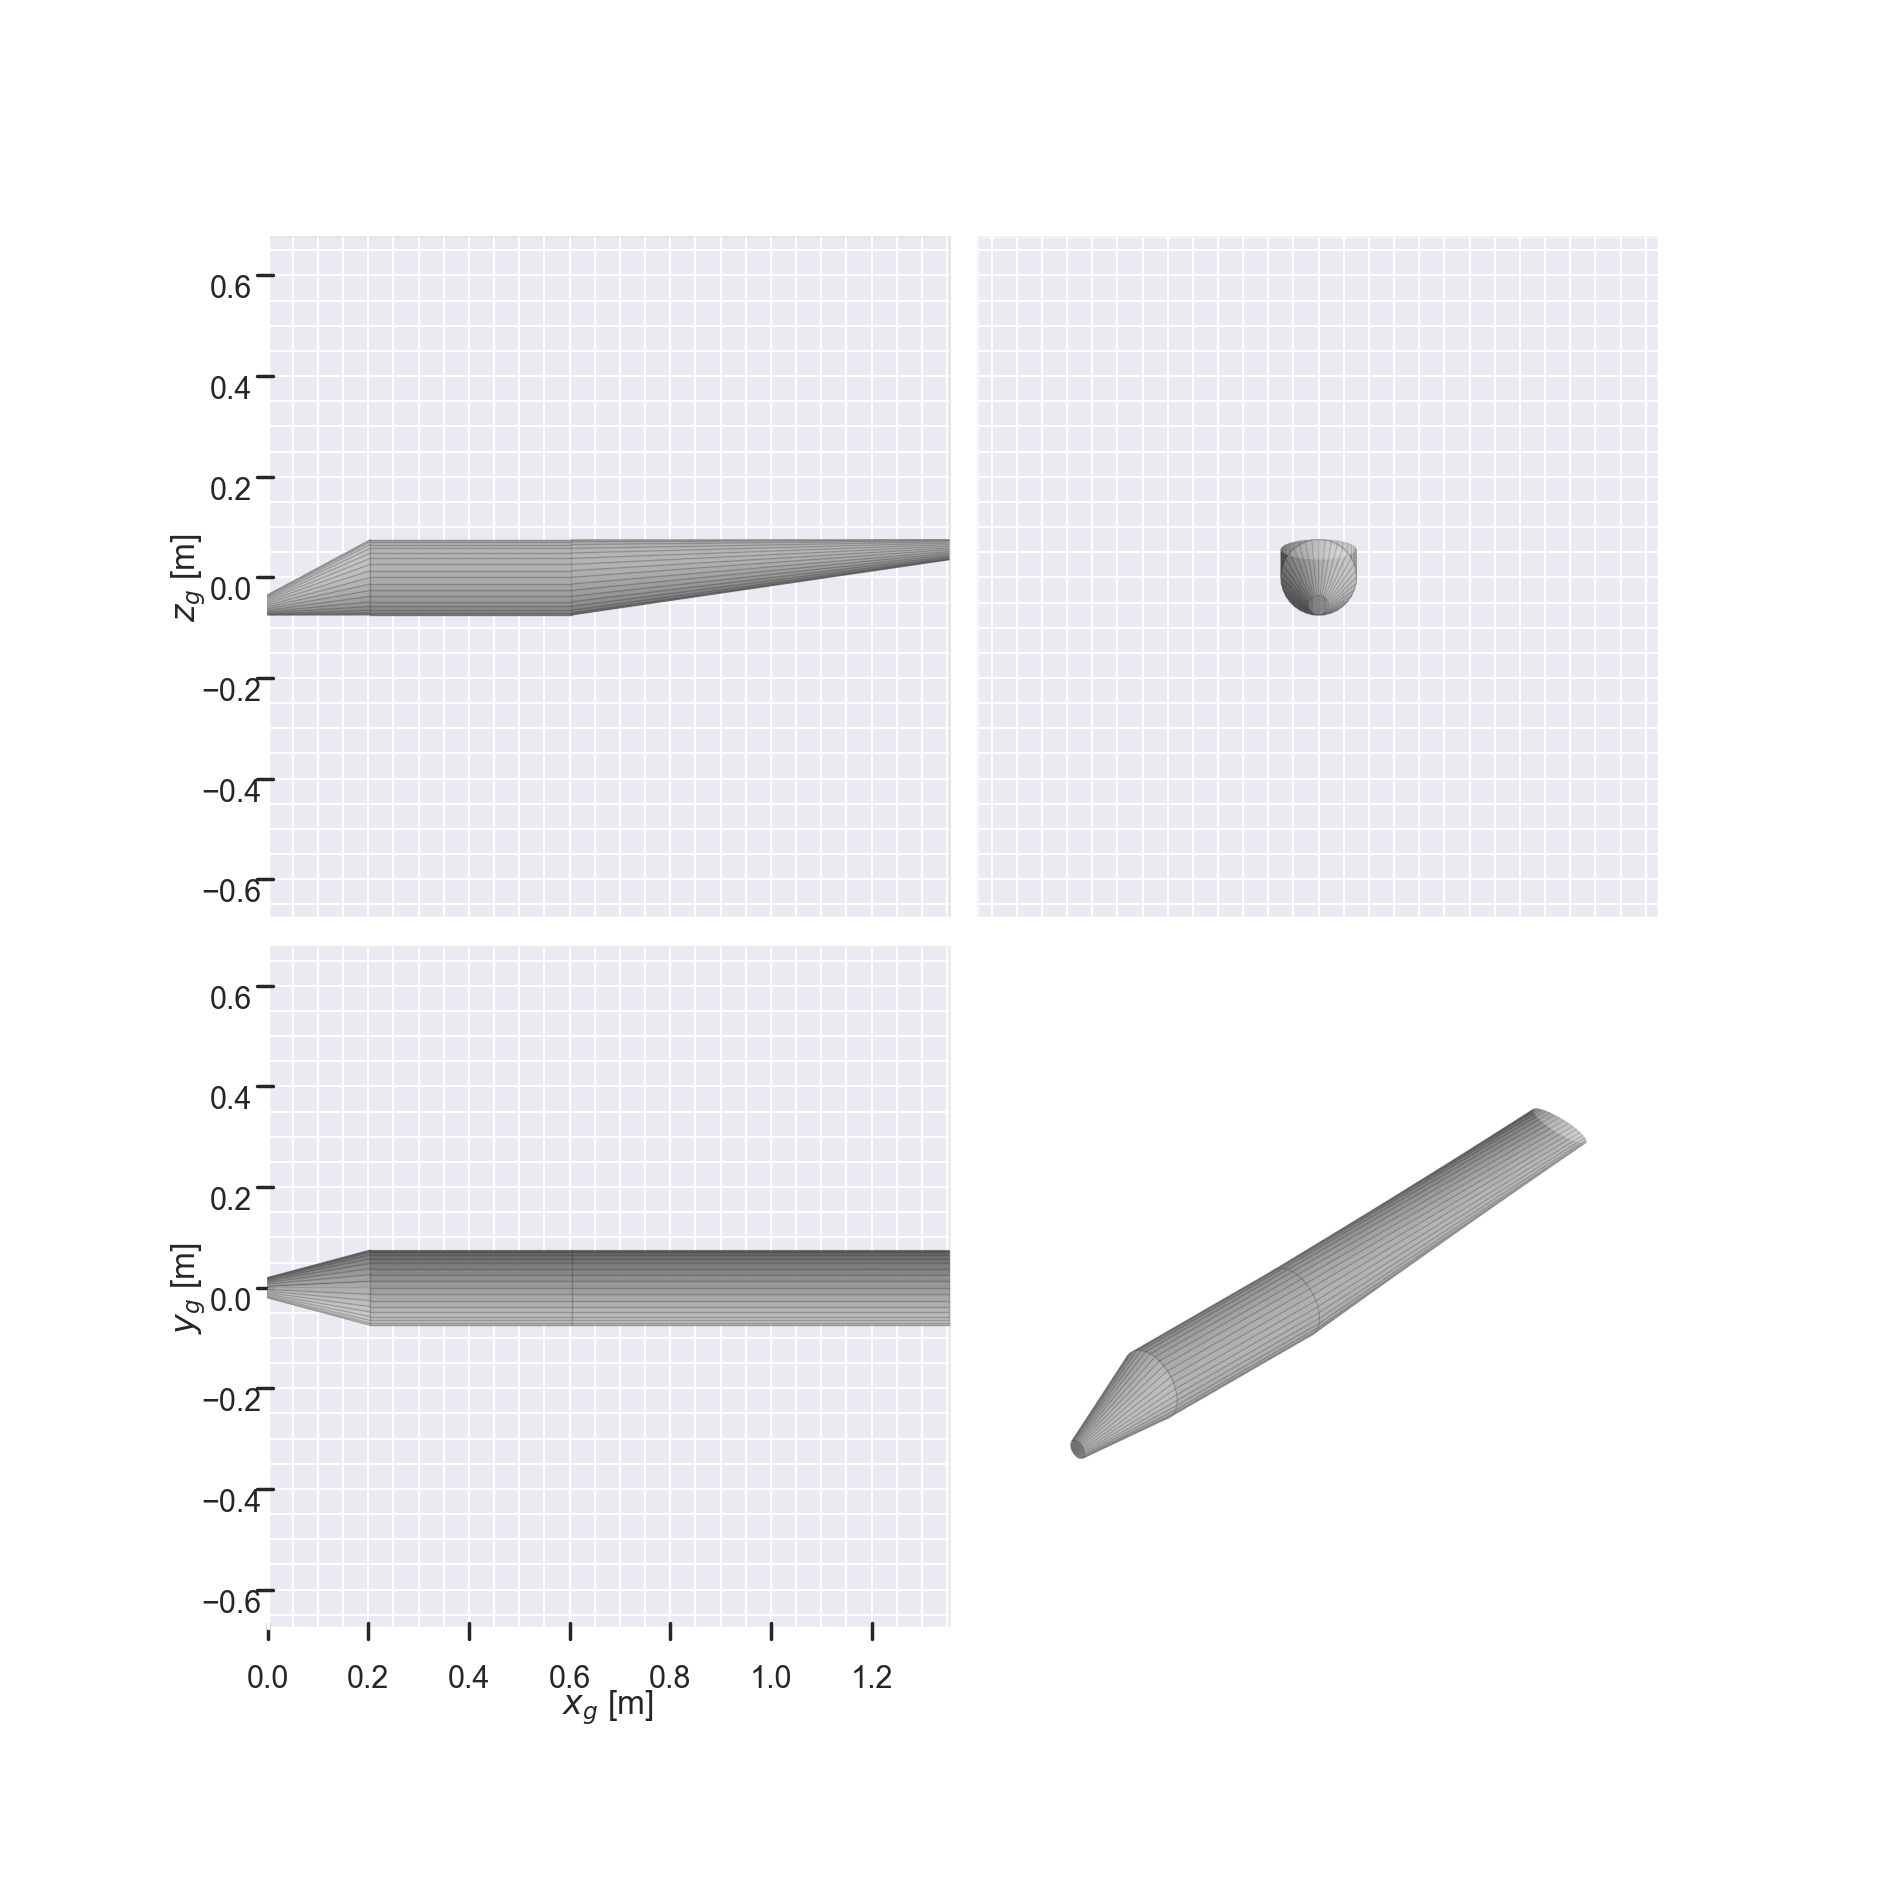

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [6]:
fuselage = asb.Fuselage(
    xsecs=[
        # Nose cone: point → body size
        asb.FuselageXSec(xyz_c=[x0, 0, -(body_h/2.0)+(nose_tip_wh/2.0)], width=nose_tip_wh, height=nose_tip_wh),
        asb.FuselageXSec(xyz_c=[x1, 0, 0], width=body_w, height=body_h),

        # Rectangular body: constant cross-section
        asb.FuselageXSec(xyz_c=[x2, 0, 0], width=body_w, height=body_h),

        # Trapezoid tail: tapers to smaller tip
        asb.FuselageXSec(xyz_c=[x3, 0, (body_h/2.0)-(tail_h/2.0)], width=tail_w, height=tail_h),
    ]
)

airplane = asb.Airplane(fuselages=[fuselage])
airplane.draw_three_view()

In [ ]:
wing = asb.Wing(
    symmetric=True,  # mirrors across y=0 (left+right)
    xsecs=[
        asb.WingXSec(
            xyz_le=[x_root, 0, z_wing],      # root leading edge
            chord=chord,
            airfoil=asb.Airfoil("naca2412"),
        ),
        asb.WingXSec(
            xyz_le=[x_tip, half_span, z_wing], # tip leading edge (sweep via x offset)
            chord=chord,
            airfoil=asb.Airfoil("naca2412"),
        ),
    ]
)

In [ ]:

def test_aero_buildup():
    analysis = asb.AeroBuildup(
        airplane=airplane,
        op_point=asb.OperatingPoint(),
    )
    aero = analysis.run()
    assert aero is not None  ### Verify analysis produces results

if __name__ == "__main__":
    test_aero_buildup()
    # or inline:
    analysis = asb.AeroBuildup(airplane=airplane, op_point=asb.OperatingPoint())
    aero = analysis.run()
    print(aero)